# Supervised Hierarchical Rao-Style PC-CNN Experiment

This notebook trains and evaluates the supervised Rao-style predictive-coding model with:

- Rao-style local visual prediction-error learning in `U1` and `U2`
- Local supervised class prediction-error learning in `W3`
- Classification error fed locally into `r2` during supervised inference
- No autograd
- No `loss.backward()`
- No optimizer


In [1]:
import copy
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from collections import defaultdict
from torch.utils.data import DataLoader, Subset

import src.data_cleaning_and_preprocessing._model_ready_dataset as model_ready_dataset
from archive.dataset.tiny_imagenet_dataset import TinyImageNetLoader
from archive.pc_cnn.py_file.pc_supervised_rao_4 import HierarchicalPCCNN

In [2]:
SEED = 42
BATCH_SIZE = 16

IMAGE_SIZE = 64
NUM_CLASSES = 5

TRAIN_IMAGES_PER_CLASS = 50
VAL_IMAGES_PER_CLASS = 15
TEST_IMAGES_PER_CLASS = 10

INFERENCE_STEPS = 100
PC_EPOCHS = 10

SIGMA_CLASS_SQ = 1.0
CLASS_POOL_SIZE = 4

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.backends.mps.is_available() and hasattr(torch.mps, "manual_seed"):
    torch.mps.manual_seed(SEED)

Device: mps


In [4]:
cleaned_tiny_imagenet = model_ready_dataset.ModelReadyDatasetLoader(TinyImageNetLoader(seed=SEED), image_size=IMAGE_SIZE).load()

train_dataset = cleaned_tiny_imagenet[0]
test_dataset = cleaned_tiny_imagenet[1]

print("Full training dataset:", len(train_dataset))
print("Full test dataset:", len(test_dataset))

Full training dataset: 99953
Full test dataset: 9993


In [5]:
selected_classes = list(range(NUM_CLASSES))

print("Selected classes:", selected_classes)
print("Number of selected classes:", len(selected_classes))

Selected classes: [0, 1, 2, 3, 4]
Number of selected classes: 5


In [6]:
class_indices = defaultdict(list)

for i in range(len(train_dataset)):
    _, label = train_dataset[i]
    label = int(label)

    if label in selected_classes:
        class_indices[label].append(i)

In [7]:
split_generator = torch.Generator()
split_generator.manual_seed(SEED)

train_indices = []
val_indices = []

for class_id in selected_classes:
    available_indices = class_indices[class_id]
    required_images = TRAIN_IMAGES_PER_CLASS + VAL_IMAGES_PER_CLASS

    if len(available_indices) < required_images:
        raise ValueError(f"Class {class_id} has only {len(available_indices)} images, but {required_images} are required.")

    permutation = torch.randperm(len(available_indices), generator=split_generator)

    train_selection = permutation[:TRAIN_IMAGES_PER_CLASS]
    val_selection = permutation[TRAIN_IMAGES_PER_CLASS:TRAIN_IMAGES_PER_CLASS + VAL_IMAGES_PER_CLASS]

    train_selected = [available_indices[i] for i in train_selection.tolist()]
    val_selected = [available_indices[i] for i in val_selection.tolist()]

    train_indices.extend(train_selected)
    val_indices.extend(val_selected)

In [8]:
train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(train_dataset, val_indices)

print("Training images:", len(train_subset))
print("Validation images:", len(val_subset))
print("Expected training images:", NUM_CLASSES * TRAIN_IMAGES_PER_CLASS)
print("Expected validation images:", NUM_CLASSES * VAL_IMAGES_PER_CLASS)

overlap = set(train_indices).intersection(set(val_indices))

print("Train/Validation overlap:", len(overlap))

assert len(overlap) == 0

Training images: 250
Validation images: 75
Expected training images: 250
Expected validation images: 75
Train/Validation overlap: 0


In [9]:
train_loader_generator = torch.Generator()
train_loader_generator.manual_seed(SEED)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, generator=train_loader_generator)
train_eval_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)

print("Training batches:", len(train_loader))
print("Training evaluation batches:", len(train_eval_loader))
print("Validation batches:", len(val_loader))

Training batches: 16
Training evaluation batches: 16
Validation batches: 5


In [10]:
test_class_indices = defaultdict(list)

for i in range(len(test_dataset)):
    _, label = test_dataset[i]
    label = int(label)

    if label in selected_classes:
        test_class_indices[label].append(i)

test_generator = torch.Generator()
test_generator.manual_seed(SEED)

test_indices = []

for class_id in selected_classes:
    available_indices = test_class_indices[class_id]

    if len(available_indices) < TEST_IMAGES_PER_CLASS:
        raise ValueError(f"Test class {class_id} has only {len(available_indices)} images, but {TEST_IMAGES_PER_CLASS} were requested.")

    permutation = torch.randperm(len(available_indices), generator=test_generator)
    selection = permutation[:TEST_IMAGES_PER_CLASS]

    selected = [available_indices[i] for i in selection.tolist()]
    test_indices.extend(selected)

test_subset = Subset(test_dataset, test_indices)
test_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False)

print("Training images:", len(train_subset))
print("Validation images:", len(val_subset))
print("Final test images:", len(test_subset))

Training images: 250
Validation images: 75
Final test images: 50


In [11]:
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.backends.mps.is_available() and hasattr(torch.mps, "manual_seed"):
    torch.mps.manual_seed(SEED)

model = HierarchicalPCCNN(num_classes=NUM_CLASSES, input_size=IMAGE_SIZE, inference_steps=INFERENCE_STEPS, convergence_tolerance=1e-5, sigma_class_sq=SIGMA_CLASS_SQ, class_pool_size=CLASS_POOL_SIZE).to(device)

print(model)
print("sigma_bu_sq:", model.sigma_bu_sq)
print("sigma_td_sq:", model.sigma_td_sq)
print("sigma_class_sq:", model.sigma_class_sq)

HierarchicalPCCNN(
  (level1): ModuleDict(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (deconv): ConvTranspose2d(32, 3, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1), bias=False)
  )
  (level2): ModuleDict(
    (conv): Conv2d(32, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (deconv): ConvTranspose2d(128, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1), bias=False)
  )
  (class_pool): AvgPool2d(kernel_size=4, stride=4, padding=0)
  (level3): ModuleDict(
    (linear): Linear(in_features=2048, out_features=5, bias=False)
  )
)
sigma_bu_sq: 1.0
sigma_td_sq: 10.0
sigma_class_sq: 1.0


In [12]:
total_params = sum(parameter.numel() for parameter in model.parameters())
autograd_params = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

print("Total unique parameters:", total_params)
print("Autograd-enabled parameters:", autograd_params)

assert autograd_params == 0

Total unique parameters: 47968
Autograd-enabled parameters: 0


In [13]:
initial_u1 = model.level1["conv"].weight.detach().cpu().clone()
initial_u2 = model.level2["conv"].weight.detach().cpu().clone()
initial_u3 = model.level3["linear"].weight.detach().cpu().clone()

print("Initial U1 norm:", initial_u1.norm().item())
print("Initial U2 norm:", initial_u2.norm().item())
print("Initial U3 norm:", initial_u3.norm().item())
print("Initial training_input_count:", model.training_input_count)
print("Initial k2:", model.k2)

Initial U1 norm: 0.30625322461128235
Initial U2 norm: 1.9177533388137817
Initial U3 norm: 1.0130559206008911
Initial training_input_count: 0
Initial k2: 1.0


In [14]:
@torch.no_grad()
def evaluate_model(model, data_loader, device, name=""):
    total_loss = 0.0
    total_correct = 0
    total_images = 0
    total_steps = 0
    total_converged = 0

    model.eval()

    for images, labels in tqdm(data_loader, desc=f"Evaluation Supervised Rao PC-CNN - {name}"):
        images = images.to(device)
        labels = labels.to(device=device, dtype=torch.long)

        result = model.classify_batch(images)

        probabilities = result["probabilities"]
        predictions = result["predictions"]

        true_probabilities = probabilities[torch.arange(labels.shape[0], device=labels.device), labels]
        loss = -torch.log(true_probabilities + 1e-8).mean().item()

        total_loss += loss * labels.shape[0]
        total_correct += (predictions == labels).sum().item()
        total_images += labels.shape[0]

        total_steps += sum(result["inference_steps"])
        total_converged += sum(int(value) for value in result["converged"])

    mean_loss = total_loss / total_images
    accuracy = 100.0 * total_correct / total_images
    mean_steps = total_steps / total_images
    convergence_rate = 100.0 * total_converged / total_images

    return mean_loss, accuracy, mean_steps, convergence_rate

In [15]:
history = []

best_val_accuracy = -1.0
best_val_loss = float("inf")

best_epoch = None
best_model_state = None
best_k2 = None
best_training_input_count = None

for epoch in range(PC_EPOCHS):
    total_error_0 = 0.0
    total_error_1 = 0.0
    total_error_2 = 0.0
    total_class_loss = 0.0
    total_steps = 0
    total_converged = 0
    total_images = 0

    model.train()

    progress_bar = tqdm(train_loader, desc=f"Supervised Rao PC-CNN Epoch {epoch + 1}/{PC_EPOCHS}")

    for images, labels in progress_bar:
        for image, label in zip(images, labels):
            image = image.to(device)
            label = label.to(device=device, dtype=torch.long)

            result = model(image, label)

            total_error_0 += result["error_0"]
            total_error_1 += result["error_1"]
            total_error_2 += result["error_2"]
            total_class_loss += result["class_loss"]

            total_steps += result["inference_steps"]
            total_converged += int(result["converged"])
            total_images += 1

    mean_error_0 = total_error_0 / total_images
    mean_error_1 = total_error_1 / total_images
    mean_error_2 = total_error_2 / total_images
    mean_class_loss = total_class_loss / total_images
    mean_steps = total_steps / total_images
    training_convergence_rate = 100.0 * total_converged / total_images

    train_loss, train_accuracy, train_eval_steps, train_eval_convergence = evaluate_model(model, train_eval_loader, device, "Train")
    val_loss, val_accuracy, val_steps, val_convergence = evaluate_model(model, val_loader, device, "Validation")

    history.append({"epoch": epoch + 1, "error_0": mean_error_0, "error_1": mean_error_1, "error_2": mean_error_2, "class_loss": mean_class_loss, "training_inference_steps": mean_steps, "training_convergence_rate": training_convergence_rate, "train_loss": train_loss, "train_accuracy": train_accuracy, "train_eval_steps": train_eval_steps, "train_eval_convergence": train_eval_convergence, "val_loss": val_loss, "val_accuracy": val_accuracy, "val_steps": val_steps, "val_convergence": val_convergence, "k2": model.k2})

    is_better = val_accuracy > best_val_accuracy

    if val_accuracy == best_val_accuracy and val_loss < best_val_loss:
        is_better = True

    if is_better:
        best_val_accuracy = val_accuracy
        best_val_loss = val_loss
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())
        best_k2 = model.k2
        best_training_input_count = model.training_input_count

    print(f"Epoch {epoch + 1}/{PC_EPOCHS} | e0: {mean_error_0:.6f} | e1: {mean_error_1:.6f} | e2: {mean_error_2:.6f} | Class Loss: {mean_class_loss:.4f} | Train Acc: {train_accuracy:.2f}% | Val Acc: {val_accuracy:.2f}% | Val Loss: {val_loss:.4f} | k2: {model.k2:.8f}")

Supervised Rao PC-CNN Epoch 1/10:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluation Supervised Rao PC-CNN - Train:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluation Supervised Rao PC-CNN - Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/10 | e0: 0.134543 | e1: 0.065491 | e2: 0.405039 | Class Loss: 1.6899 | Train Acc: 27.60% | Val Acc: 33.33% | Val Loss: 1.5685 | k2: 0.91454219


Supervised Rao PC-CNN Epoch 2/10:   0%|          | 0/16 [00:00<?, ?it/s]

...

Epoch 9/10 | e0: 0.069681 | e1: 0.047659 | e2: 0.343279 | Class Loss: 1.2213 | Train Acc: 49.60% | Val Acc: 49.33% | Val Loss: 1.2824 | k2: 0.43441182


Supervised Rao PC-CNN Epoch 10/10:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluation Supervised Rao PC-CNN - Train:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluation Supervised Rao PC-CNN - Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 10/10 | e0: 0.067456 | e1: 0.047786 | e2: 0.340764 | Class Loss: 1.2020 | Train Acc: 51.60% | Val Acc: 46.67% | Val Loss: 1.2747 | k2: 0.39728794


In [16]:
trained_u1 = model.level1["conv"].weight.detach().cpu()
trained_u2 = model.level2["conv"].weight.detach().cpu()
trained_u3 = model.level3["linear"].weight.detach().cpu()

print("AFTER TRAINING")
print("training_input_count:", model.training_input_count)
print("k2:", model.k2)

print("U1 norm:", trained_u1.norm().item())
print("U2 norm:", trained_u2.norm().item())
print("U3 norm:", trained_u3.norm().item())

print("U1 change:", torch.norm(trained_u1 - initial_u1).item())
print("U2 change:", torch.norm(trained_u2 - initial_u2).item())
print("U3 change:", torch.norm(trained_u3 - initial_u3).item())

AFTER TRAINING
training_input_count: 2500
k2: 0.39728793877051816
U1 norm: 1.1537566184997559
U2 norm: 2.8848283290863037
U3 norm: 2.427490472793579
U1 change: 1.0061588287353516
U2 change: 2.3110811710357666
U3 change: 2.031172275543213


In [17]:
if best_model_state is None:
    raise RuntimeError("No model checkpoint was saved.")

model.load_state_dict(best_model_state)
model.k2 = best_k2
model.training_input_count = best_training_input_count
model.eval()

print("Best epoch:", best_epoch)
print("Best validation accuracy:", f"{best_val_accuracy:.2f}%")
print("Best validation loss:", f"{best_val_loss:.4f}")

Best epoch: 9
Best validation accuracy: 49.33%
Best validation loss: 1.2824


In [18]:
print("=" * 60)
print("BEST CHECKPOINT DIAGNOSTICS")
print("=" * 60)

print("Best epoch:", best_epoch)
print("training_input_count:", model.training_input_count)
print("k2:", model.k2)

print("U1 norm:", model.level1["conv"].weight.norm().item())
print("U2 norm:", model.level2["conv"].weight.norm().item())
print("U3 norm:", model.level3["linear"].weight.norm().item())

print("U1 change from initialization:", torch.norm(model.level1["conv"].weight.detach().cpu() - initial_u1).item())
print("U2 change from initialization:", torch.norm(model.level2["conv"].weight.detach().cpu() - initial_u2).item())
print("U3 change from initialization:", torch.norm(model.level3["linear"].weight.detach().cpu() - initial_u3).item())

BEST CHECKPOINT DIAGNOSTICS
Best epoch: 9
training_input_count: 2250
k2: 0.434411820494279
U1 norm: 1.1373848915100098
U2 norm: 2.8642046451568604
U3 norm: 2.3496837615966797
U1 change from initialization: 0.9908196926116943
U2 change from initialization: 2.2746269702911377
U3 change from initialization: 1.949836015701294


In [19]:
@torch.no_grad()
def evaluate_per_class(model, data_loader, device, num_classes):
    class_correct = torch.zeros(num_classes, dtype=torch.long)
    class_total = torch.zeros(num_classes, dtype=torch.long)

    model.eval()

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device=device, dtype=torch.long)

        result = model.classify_batch(images)
        predictions = result["predictions"]

        for class_id in range(num_classes):
            mask = labels == class_id
            class_correct[class_id] += (predictions[mask] == labels[mask]).sum().cpu()
            class_total[class_id] += mask.sum().cpu()

    for class_id in range(num_classes):
        accuracy = 100.0 * class_correct[class_id].item() / class_total[class_id].item()
        print(f"Class {class_id} | Correct: {class_correct[class_id].item()}/{class_total[class_id].item()} | Accuracy: {accuracy:.2f}%")

evaluate_per_class(model, val_loader, device, NUM_CLASSES)

Class 0 | Correct: 13/15 | Accuracy: 86.67%
Class 1 | Correct: 2/15 | Accuracy: 13.33%
Class 2 | Correct: 3/15 | Accuracy: 20.00%
Class 3 | Correct: 9/15 | Accuracy: 60.00%
Class 4 | Correct: 10/15 | Accuracy: 66.67%


In [20]:
with torch.no_grad():
    for class_id in range(NUM_CLASSES):
        print(f"U3 class {class_id} norm:", model.level3["linear"].weight[class_id].norm().item())

with torch.no_grad():
    u3 = model.level3["linear"].weight.detach()
    similarity = F.cosine_similarity(u3.unsqueeze(1), u3.unsqueeze(0), dim=2)

print("U3 class-weight cosine similarity:")
print(similarity.cpu())

U3 class 0 norm: 1.3758794069290161
U3 class 1 norm: 0.9978092312812805
U3 class 2 norm: 0.8499652743339539
U3 class 3 norm: 0.8790543079376221
U3 class 4 norm: 1.0663812160491943
U3 class-weight cosine similarity:
tensor([[ 1.0000, -0.3897, -0.2447, -0.2379, -0.4525],
        [-0.3897,  1.0000, -0.2038, -0.0111, -0.1393],
        [-0.2447, -0.2038,  1.0000, -0.2345,  0.0114],
        [-0.2379, -0.0111, -0.2345,  1.0000, -0.2197],
        [-0.4525, -0.1393,  0.0114, -0.2197,  1.0000]])


In [21]:
model.eval()

for class_id in selected_classes:
    for image, label in train_subset:
        if int(label) == class_id:
            result = model.classify(image.to(device))

            print("True class:", class_id)
            print("Scores:", result["scores"].detach().cpu().flatten())
            print("Probabilities:", result["probabilities"].detach().cpu().flatten())
            print("Predicted class:", result["prediction"].item())
            print()
            break

True class: 0
Scores: tensor([ 1.6041, -0.4863, -0.3123, -0.0078, -0.9478])
Probabilities: tensor([0.6459, 0.0799, 0.0950, 0.1289, 0.0503])
Predicted class: 0

True class: 1
Scores: tensor([ 0.1352,  0.0029, -0.0889,  0.1656, -0.3652])
Probabilities: tensor([0.2319, 0.2032, 0.1853, 0.2390, 0.1406])
Predicted class: 3

True class: 2
Scores: tensor([-0.5271, -0.1137,  0.1423,  0.2827,  0.0291])
Probabilities: tensor([0.1182, 0.1788, 0.2310, 0.2658, 0.2062])
Predicted class: 3

True class: 3
Scores: tensor([-0.9130,  0.2114, -0.1374,  0.5733,  0.1074])
Probabilities: tensor([0.0744, 0.2290, 0.1615, 0.3288, 0.2063])
Predicted class: 3

True class: 4
Scores: tensor([-0.8437,  0.0579, -0.0448,  0.3613,  0.2739])
Probabilities: tensor([0.0828, 0.2039, 0.1840, 0.2762, 0.2531])
Predicted class: 3



In [22]:
final_train_loss, final_train_accuracy, final_train_steps, final_train_convergence = evaluate_model(model, train_eval_loader, device, "Train")
final_val_loss, final_val_accuracy, final_val_steps, final_val_convergence = evaluate_model(model, val_loader, device, "Validation")

print("RESTORED BEST MODEL")
print("Train Loss:", f"{final_train_loss:.4f}")
print("Train Accuracy:", f"{final_train_accuracy:.2f}%")
print("Validation Loss:", f"{final_val_loss:.4f}")
print("Validation Accuracy:", f"{final_val_accuracy:.2f}%")

Evaluation Supervised Rao PC-CNN - Train:   0%|          | 0/16 [00:00<?, ?it/s]

Evaluation Supervised Rao PC-CNN - Validation:   0%|          | 0/5 [00:00<?, ?it/s]

RESTORED BEST MODEL
Train Loss: 1.2948
Train Accuracy: 49.60%
Validation Loss: 1.2824
Validation Accuracy: 49.33%


In [23]:
test_loss, test_accuracy, test_steps, test_convergence = evaluate_model(model, test_loader, device, "Test")

print("FINAL CLEAN TEST RESULT")
print("Test Loss:", f"{test_loss:.4f}")
print("Test Accuracy:", f"{test_accuracy:.2f}%")
print("Mean Inference Steps:", f"{test_steps:.2f}")
print("Convergence Rate:", f"{test_convergence:.2f}%")

Evaluation Supervised Rao PC-CNN - Test:   0%|          | 0/4 [00:00<?, ?it/s]

FINAL CLEAN TEST RESULT
Test Loss: 1.3305
Test Accuracy: 44.00%
Mean Inference Steps: 100.00
Convergence Rate: 0.00%


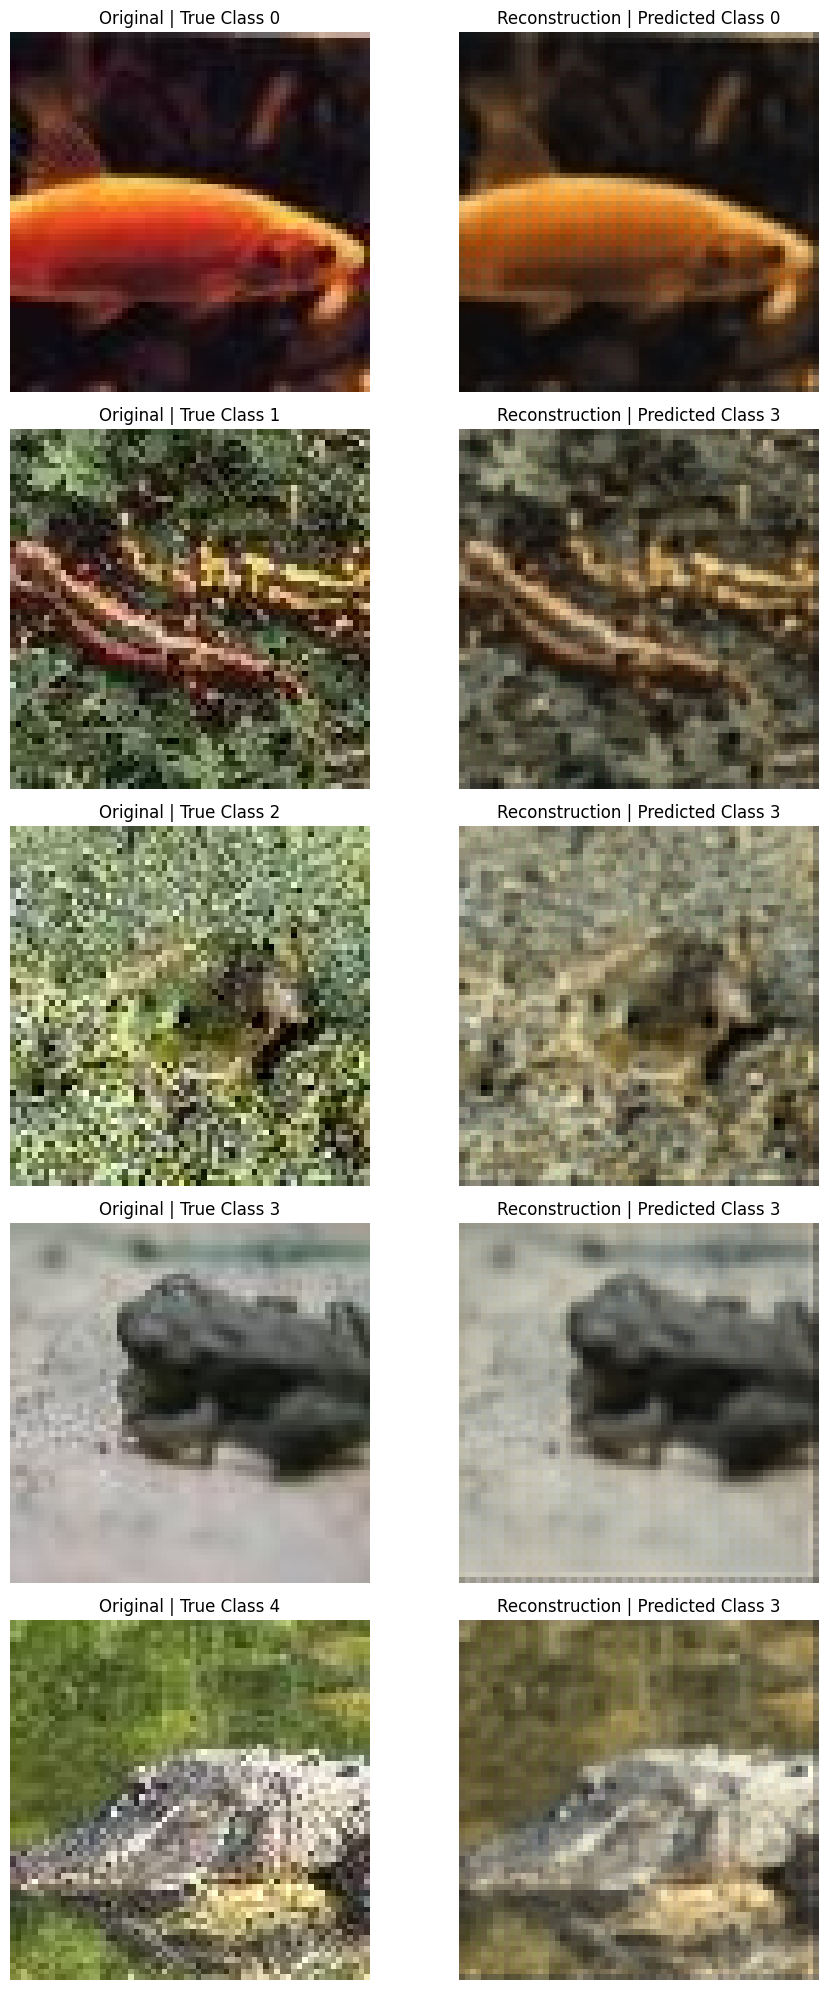

In [24]:
def to_display_image(image):
    image = image.detach().cpu().clamp(0, 1)
    return image.permute(1, 2, 0).numpy()

model.eval()

class_examples = {}

for i in range(len(train_subset)):
    image, label = train_subset[i]
    label = int(label)

    if label not in class_examples:
        class_examples[label] = image

    if len(class_examples) == NUM_CLASSES:
        break

fig, axes = plt.subplots(NUM_CLASSES, 2, figsize=(10, NUM_CLASSES * 4))

for row, class_id in enumerate(selected_classes):
    image = class_examples[class_id]

    reconstruction, predicted_r1, r2, probabilities, predicted_class, steps, converged = model.reconstruct(image)

    axes[row, 0].imshow(to_display_image(image))
    axes[row, 0].set_title(f"Original | True Class {class_id}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(to_display_image(reconstruction))
    axes[row, 1].set_title(f"Reconstruction | Predicted Class {predicted_class}")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

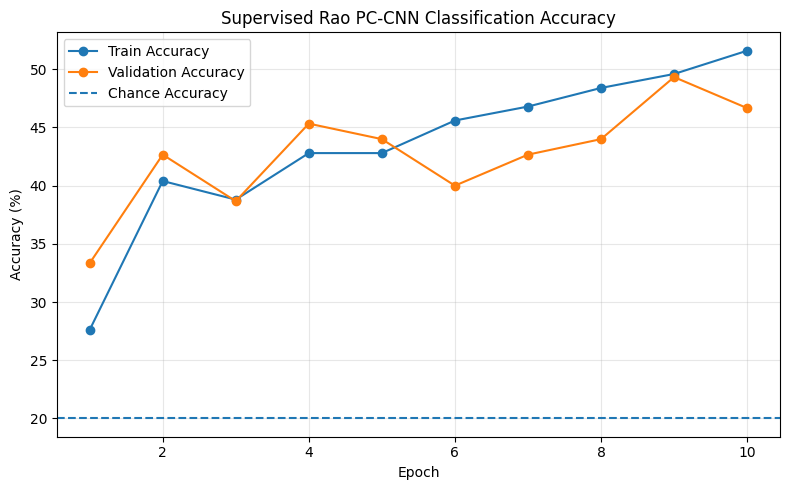

In [25]:
epochs_plot = [item["epoch"] for item in history]
train_accuracy_plot = [item["train_accuracy"] for item in history]
val_accuracy_plot = [item["val_accuracy"] for item in history]

plt.figure(figsize=(8, 5))
plt.plot(epochs_plot, train_accuracy_plot, marker="o", label="Train Accuracy")
plt.plot(epochs_plot, val_accuracy_plot, marker="o", label="Validation Accuracy")
plt.axhline(100.0 / NUM_CLASSES, linestyle="--", label="Chance Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Supervised Rao PC-CNN Classification Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

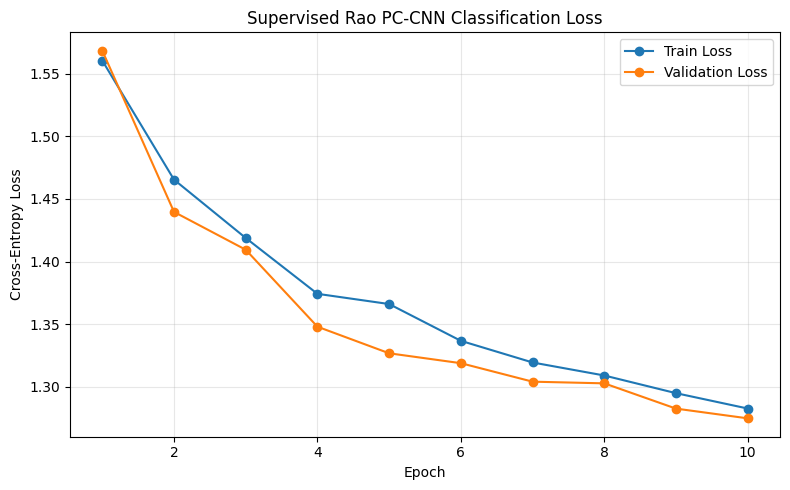

In [26]:
train_loss_plot = [item["train_loss"] for item in history]
val_loss_plot = [item["val_loss"] for item in history]

plt.figure(figsize=(8, 5))
plt.plot(epochs_plot, train_loss_plot, marker="o", label="Train Loss")
plt.plot(epochs_plot, val_loss_plot, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Supervised Rao PC-CNN Classification Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

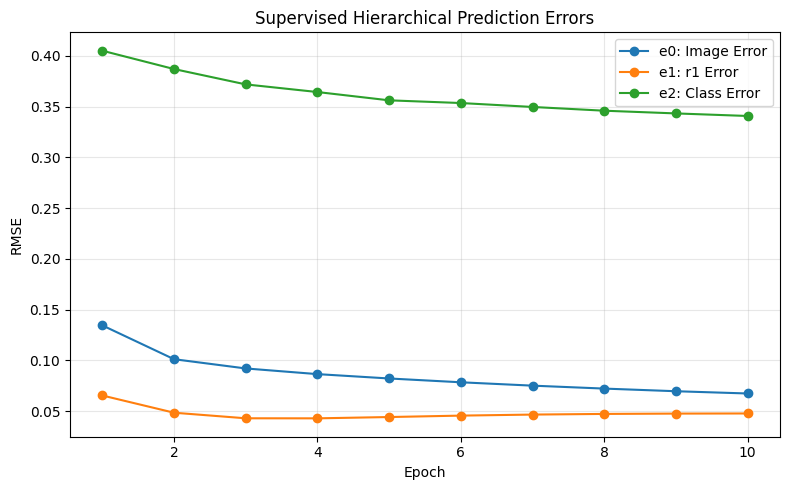

In [27]:
error_0_plot = [item["error_0"] for item in history]
error_1_plot = [item["error_1"] for item in history]
error_2_plot = [item["error_2"] for item in history]

plt.figure(figsize=(8, 5))
plt.plot(epochs_plot, error_0_plot, marker="o", label="e0: Image Error")
plt.plot(epochs_plot, error_1_plot, marker="o", label="e1: r1 Error")
plt.plot(epochs_plot, error_2_plot, marker="o", label="e2: Class Error")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Supervised Hierarchical Prediction Errors")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

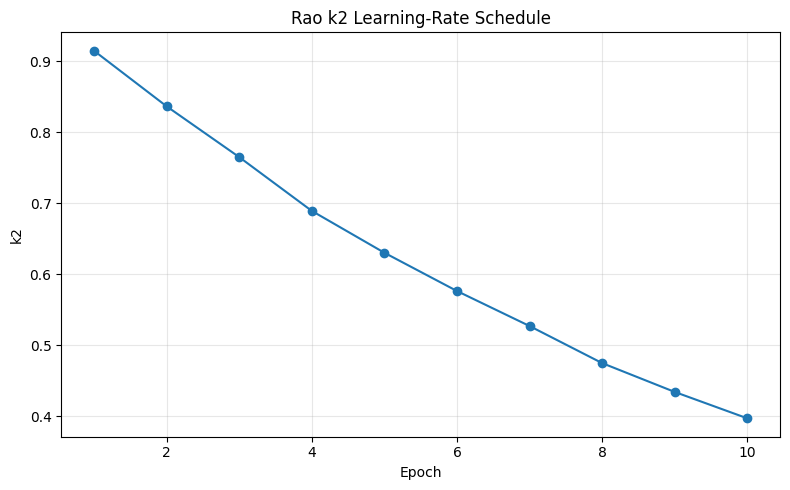

In [28]:
k2_plot = [item["k2"] for item in history]

plt.figure(figsize=(8, 5))
plt.plot(epochs_plot, k2_plot, marker="o")
plt.xlabel("Epoch")
plt.ylabel("k2")
plt.title("Rao k2 Learning-Rate Schedule")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
print("=" * 65)
print("SUPERVISED HIERARCHICAL RAO PC-CNN EXPERIMENT SUMMARY")
print("=" * 65)

print("Device:", device)
print("Input size:", IMAGE_SIZE)
print("Number of classes:", NUM_CLASSES)

print("Training images:", len(train_subset))
print("Validation images:", len(val_subset))
print("Test images:", len(test_subset))

print("Training epochs:", PC_EPOCHS)
print("Inference steps:", INFERENCE_STEPS)
print("Convergence tolerance:", model.convergence_tolerance)
print("sigma_class_sq:", model.sigma_class_sq)

print("Best epoch:", best_epoch)
print("Best validation accuracy:", f"{best_val_accuracy:.2f}%")

print("Final training accuracy:", f"{final_train_accuracy:.2f}%")
print("Final validation accuracy:", f"{final_val_accuracy:.2f}%")

print("Final clean test loss:", f"{test_loss:.4f}")
print("Final clean test accuracy:", f"{test_accuracy:.2f}%")
print("Final clean test convergence:", f"{test_convergence:.2f}%")

print("Training presentations at best epoch:", model.training_input_count)
print("k2 at best epoch:", model.k2)

print("=" * 65)

SUPERVISED HIERARCHICAL RAO PC-CNN EXPERIMENT SUMMARY
Device: mps
Input size: 64
Number of classes: 5
Training images: 250
Validation images: 75
Test images: 50
Training epochs: 10
Inference steps: 100
Convergence tolerance: 1e-05
sigma_class_sq: 1.0
Best epoch: 9
Best validation accuracy: 49.33%
Final training accuracy: 49.60%
Final validation accuracy: 49.33%
Final clean test loss: 1.3305
Final clean test accuracy: 44.00%
Final clean test convergence: 0.00%
Training presentations at best epoch: 2250
k2 at best epoch: 0.434411820494279
